<a href="https://colab.research.google.com/github/RajeshRanaGiet/AML-LAB/blob/main/Experiment%202/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

print("Please enter comma-separated numerical values for the following fields:")
study_hours_input = input("Enter the study hours (e.g., 2,4,6,8): ")
attendance_input = input("Enter the attendance (e.g., 70,80,85,90): ")
assignment_input = input("Enter the assignment scores (e.g., 12,15,18,20): ")
exam_marks_input = input("Enter the exam marks (e.g., 45,60,75,90): ")

study_hours = np.array([float(x) for x in study_hours_input.split(",") if x.strip()])
attendance = np.array([float(x) for x in attendance_input.split(",") if x.strip()])
assignment = np.array([float(x) for x in assignment_input.split(",") if x.strip()])
exam_marks = np.array([float(x) for x in exam_marks_input.split(",") if x.strip()])

if not (len(study_hours) == len(attendance) == len(assignment) == len(exam_marks)):
    print("\nError: All input fields must contain the exact same number of data points.")
elif len(study_hours) < 2:
    print("\nError: Please enter at least 2 or more data points.")
else:
    data = pd.DataFrame({
        'x1': study_hours,
        'x2': attendance,
        'x3': assignment
    })

    model = LinearRegression()
    model.fit(data, exam_marks)

    intercept = model.intercept_
    coefficients = model.coef_

    equation_terms = [f"({coef:.4f} * x{i+1})" for i, coef in enumerate(coefficients)]
    equation_str = f"y = {intercept:.4f} + " + " + ".join(equation_terms)

    print("Final Regression Equation:")
    print(equation_str)
    print(f"Intercept (b0): {intercept:.4f}")
    for idx, coef in enumerate(coefficients):
        print(f"Slope for {x_names[idx]} (b{idx+1}): {coef:.4f}")
    print(f"Mean Squared Error (MSE)       : {mse:.4f}")
    print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
    print(f"R² Score                       : {r2:.4f}")
    print()

    while True:
        choice = input("Do you want to enter sample data (study hours, attendance, assignment) for predicting the mark? (yes/no): ").strip().lower()

        if choice in ['yes', 'y']:
            try:
                print("\n--- Enter Values for Prediction ---")
                x1_val = float(input("Enter Study Hours (x1): "))
                x2_val = float(input("Enter Attendance (x2): "))
                x3_val = float(input("Enter Assignment Score (x3): "))

                sample_df = pd.DataFrame([{
                    'x1': x1_val,
                    'x2': x2_val,
                    'x3': x3_val
                }])

                predicted_mark = model.predict(sample_df)[0]
                print(f">> Predicted Exam Mark (y): {predicted_mark:.4f}\n")
            except ValueError:
                print("Invalid input! Please enter numeric values.\n")

        elif choice in ['no', 'n']:
            print("Exiting program. Goodbye!")
            break
        else:
            print("Please answer with 'yes' or 'no'.\n")

#Testing data :- 6,85,18,75

Please enter comma-separated numerical values for the following fields:
Enter the study hours (e.g., 2,4,6,8): 2,4,6,8
Enter the attendance (e.g., 70,80,85,90): 70,80,85,90
Enter the assignment scores (e.g., 12,15,18,20): 12,15,18,20
Enter the exam marks (e.g., 45,60,75,90): 45,60,75,90

Final Regression Equation:
y = 30.0000 + (7.5000 * x1) + (-0.0000 * x2) + (0.0000 * x3)
Intercept (b0): 30.0000
Slope (b1): 7.5000
Slope (b2): -0.0000
Slope (b3): 0.0000

Do you want to enter sample data (study hours, attendance, assignment) for predicting the mark? (yes/no): y

--- Enter Values for Prediction ---
Enter Study Hours (x1): 6
Enter Attendance (x2): 85
Enter Assignment Score (x3): 18
>> Predicted Exam Mark (y): 75.0000

Do you want to enter sample data (study hours, attendance, assignment) for predicting the mark? (yes/no): n
Exiting program. Goodbye!


Enter the name of the target variable y : Final Marks
Enter comma-separated numerical values for Final Marks (y): 45,60,75,90

How many feature variables (x) do you want to enter? 3

Please enter comma-separated numerical values for each feature:
Enter the name of feature x1 : Study Hours
Enter values for Study Hours (x1): 2,6,4,8
Enter the name of feature x2 : Attendance
Enter values for Attendance (x2): 70,80,85,90
Enter the name of feature x3 : Assignment
Enter values for Assignment (x3): 12,15,18,20

Final Regression Equation:
y = 60.0000 + (1.5000 * x1) + (-1.8000 * x2) + (9.0000 * x3)
Intercept (b0): 60.0000
Slope for Study Hours (b1): 1.5000
Slope for Attendance (b2): -1.8000
Slope for Assignment (b3): 9.0000

Do you want to enter sample data for predicting Final Marks? (yes/no): y

--- Enter Values for Prediction ---
Enter value for Study Hours (x1): 6
Enter value for Attendance (x2): 85
Enter value for Assignment (x3): 18
>> Predicted Final Marks (y): 78.0000



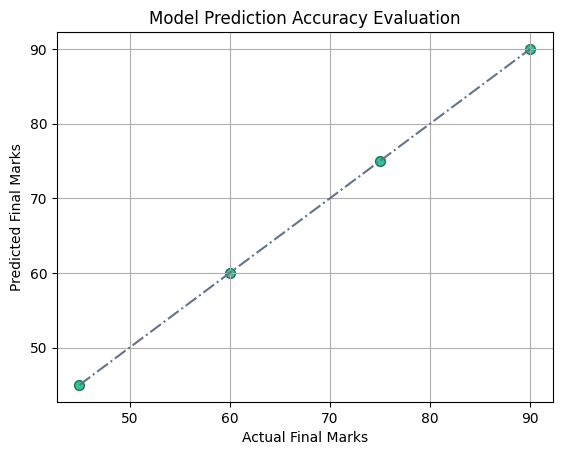

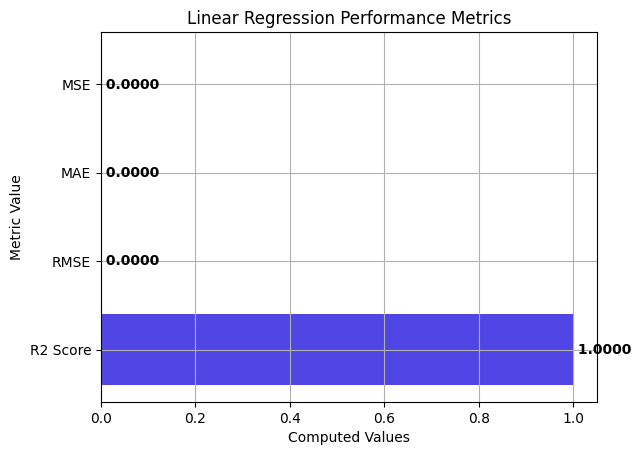

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

y_name = input("Enter the name of the target variable y : ").strip()
y_input = input(f"Enter comma-separated numerical values for {y_name} (y): ")
y_vals = np.array([float(val) for val in y_input.split(",") if val.strip()])
num_data_points = len(y_vals)

num_features = int(input("\nHow many feature variables (x) do you want to enter? "))

x_data = {}
x_names = []
validation_passed = True

print("\nPlease enter comma-separated numerical values for each feature:")
for i in range(num_features):
    feat_name = input(f"Enter the name of feature x{i+1} : ").strip()
    x_names.append(feat_name)

    feat_input = input(f"Enter values for {feat_name} (x{i+1}): ")
    feat_vals = np.array([float(val) for val in feat_input.split(",") if val.strip()])

    if len(feat_vals) != num_data_points:
        print(f"\nError: '{feat_name}' has {len(feat_vals)} data points, but {y_name} has {num_data_points}.")
        validation_passed = False
        break

    x_data[f'x{i+1}'] = feat_vals

if not validation_passed:
    print("\nExecution stopped due to mismatched data point lengths.")
elif num_data_points < 2:
    print("\nError: Please enter at least 2 or more data points.")
else:
    data = pd.DataFrame(x_data)

    model = LinearRegression()
    model.fit(data, y_vals)
    predictions = model.predict(data)
    mse = mean_squared_error(y_vals, predictions)
    mae = mean_absolute_error(y_vals, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_vals, predictions)
    intercept = model.intercept_
    coefficients = model.coef_
    equation_terms = [f"({coef:.4f} * x{idx+1})" for idx, coef in enumerate(coefficients)]
    equation_str = f"y = {intercept:.4f} + " + " + ".join(equation_terms)

    print("\n==============================")
    print("Final Regression Equation:")
    print(equation_str)
    print("==============================")
    print(f"Intercept (b0): {intercept:.4f}")
    for idx, coef in enumerate(coefficients):
        print(f"Slope for {x_names[idx]} (b{idx+1}): {coef:.4f}")
    print()

    choice = input(f"Do you want to enter sample data for predicting {y_name}? (yes/no): ").strip().lower()

    if choice in ['yes', 'y']:
        try:
            print(f"\n--- Enter Values for Prediction ---")
            sample_dict = {}
            for idx, name in enumerate(x_names):
                val = float(input(f"Enter value for {name} (x{idx+1}): "))
                sample_dict[f'x{idx+1}'] = val

            sample_df = pd.DataFrame([sample_dict])
            predicted_val = model.predict(sample_df)[0]
            print(f">> Predicted {y_name} (y): {predicted_val:.4f}\n")
        except ValueError:
            print("Invalid input! Please enter numeric values.\n")

    elif choice in ['no', 'n']:
        print("Exiting prediction menu. Displaying graphs...\n")
    else:
        print("Invalid Input.\n")

    first_x_key = 'x1'
    first_x_vals = x_data[first_x_key]
    first_x_name = x_names[0]


    plt.scatter(y_vals, predictions, color="#10b981", edgecolor="#065f46", linewidth=1, s=50, alpha=0.85)
    min_val = min(float(np.min(y_vals)), float(np.min(predictions)))
    max_val = max(float(np.max(y_vals)), float(np.max(predictions)))
    plt.plot([min_val, max_val], [min_val, max_val], color="#64748b", linestyle="-.", linewidth=1.5)
    plt.xlabel(f"Actual {y_name}")
    plt.ylabel(f"Predicted {y_name}")
    plt.title("Model Prediction Accuracy Evaluation")
    plt.grid(True)
    plt.show()

    metrics_names = ["R2 Score", "RMSE", "MAE", "MSE"]
    metrics_vals = [r2, rmse, mae, mse]
    colors = ["#4f46e5", "#3b82f6", "#60a5fa", "#93c5fd"]
    bars = plt.barh(metrics_names, metrics_vals, color=colors)
    for bar in bars:
        width = bar.get_width()
        plt.annotate(f" {width:.4f}", xy=(width, bar.get_y() + bar.get_height() / 2), ha='left', va='center', fontweight='bold')
    plt.xlabel("Computed Values")
    plt.ylabel("Metric Value")
    plt.title("Linear Regression Performance Metrics")
    plt.grid(True)
    plt.show()
